In [51]:
import pandas as pd
df = pd.read_csv("healthcare_data_cleaning_dataset.csv")   # use your actual file name/path
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [11]:
#Q1. Missing Data Identification
#Task:
#Identify missing values in each column
#Calculate percentage of missing data
df.info()
#1
missing_count = df.isnull().sum()
print(missing_count)
print("-"*100)
missing_percent = round((df.isnull().sum() / len(df)) * 100,2)
total_count=len(df)
print(missing_percent)
print("-"*100)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "Total Count" :total_count,
    "missing_percent": missing_percent
    
})

print(missing_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          5100 non-null   int64  
 1   Age                 4500 non-null   float64
 2   Gender              5100 non-null   object 
 3   City                5100 non-null   object 
 4   Diagnosis           5100 non-null   object 
 5   Hospital_Visits     5100 non-null   int64  
 6   Treatment_Cost      4507 non-null   float64
 7   Insurance_Coverage  5100 non-null   int64  
 8   Admission_Date      5100 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 358.7+ KB
Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64
--------------------------------------------

In [27]:
#Q2. Handling Missing Age
#Scenario: 
 #Age is critical for medical analysis, but some values are missing.
#Task:
#Replace missing Age values with an appropriate method
#Justify your choice (mean/median)
#1)
before_missing_count = df.isnull().sum()
print(before_missing_count)
age_median = df['Age'].median()
print("-"*100)
print("Age Median")
print( age_median)
print("-"*100)
df['Age'] = df['Age'].fillna(age_median)

after_missing_count = df.isnull().sum()
print(missing_count)
print("-"*100)
missing_percent = round((df.isnull().sum() / len(df)) * 100,2)
total_count=len(df)
#print(missing_percent)
print("-"*100)
missing_summary = pd.DataFrame({
    "Before missing count":before_missing_count,
    "After missing_count": after_missing_count,
    "Total Count" :total_count,
    "missing_percent": missing_percent
    
})

print(missing_summary)
#2)
print("\n\nReplaced missing values in the Age column using the median Age of the available records. Median imputation is suitable for continuous clinical variables like age because it is robust to extreme values and outliers and better represents the central tendency when the data are skewed.")

Patient_ID              0
Age                     0
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64
----------------------------------------------------------------------------------------------------
Age Median
50.0
----------------------------------------------------------------------------------------------------
Patient_ID              0
Age                     0
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
                    Before missing count  After missing_count  Total Count  \
Patient_

In [40]:
#Q3. Handling Missing Treatment Cost
#Scenario: 
 #Treatment cost is highly skewed due to expensive treatments.
#Task:
#Handle missing Treatment_Cost values
#Choose the correct imputation method and explain why
df['Treatment_Cost'].isnull().sum()
print(df['Treatment_Cost'].describe())

# Median treatment cost from your describe()
treat_median = 24797.0  # 50% value from describe

# Impute missing values
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(treat_median)

# Check
print("\nNo of Treatment_Cost is null ", df['Treatment_Cost'].isnull().sum())

treat_median_after = df['Treatment_Cost'].median()
print("\nAfter Correction median " ,treat_median_after)

print("\n\n\nThe Treatment_Cost variable is continuous and highly right‑skewed. The mean treatment cost is 26,920.15, while the median is lower at 24,797, and the maximum value (199,702.97) is much higher than the upper quartile (37,922), indicating the presence of a few very expensive treatments that act as outliers. Because of this skewness, I imputed missing values in Treatment_Cost using the median (24,797) rather than the mean. Median imputation is more appropriate for skewed numerical data, as it is robust to extreme values and better reflects the typical cost for most patients")



count      5100.000000
mean      26673.282797
std       21843.310975
min         526.000000
25%       14053.250000
50%       24797.000000
75%       36309.500000
max      199702.965333
Name: Treatment_Cost, dtype: float64

No of Treatment_Cost is null  0

After Correction median  24797.0



The Treatment_Cost variable is continuous and highly right‑skewed. The mean treatment cost is 26,920.15, while the median is lower at 24,797, and the maximum value (199,702.97) is much higher than the upper quartile (37,922), indicating the presence of a few very expensive treatments that act as outliers. Because of this skewness, I imputed missing values in Treatment_Cost using the median (24,797) rather than the mean. Median imputation is more appropriate for skewed numerical data, as it is robust to extreme values and better reflects the typical cost for most patients


In [45]:
#Q4. Duplicate Patient Records
#Scenario: 
 #Some patient records were entered multiple times.
#Task:
#Identify duplicate rows
#Remove duplicates
#Compare dataset size before and after
rows_before, cols = df.shape
print("Before correction " ,rows_before, cols)

# Boolean mask of duplicate rows (True = duplicate of a previous row)
dup_mask = df.duplicated()

# Count of duplicate rows
dup_count = dup_mask.sum()
print("Duplicate count ", dup_count)

df[dup_mask].head()

#Remove duplicates (keep first occurrence)
df_clean = df.drop_duplicates(keep='first')

rows_after, after_cols =df_clean.shape
print("After correction " ,rows_after,after_cols)

Before correction  5100 9
Duplicate count  99
After correction  5001 9


In [52]:
#Q5. Invalid Age Values (Data Quality Check)
#Scenario: 
 #Some patients have unrealistic age values (e.g., >100 or <0).
#Task:
#Detect such records
#Decide whether to remove or correct them

# condition for invalid age
invalid_age_mask = (df['Age'] < 0) | (df['Age'] > 100)

# see how many invalid ages
invalid_age_count = invalid_age_mask.sum()
invalid_age_count

# view some invalid records
df[invalid_age_mask].head()

# rows before
rows_before = len(df)

# keep only valid ages between 0 and 100 inclusive
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]
print(df)
# rows after
rows_after = len(df)

rows_removed = rows_before - rows_after
print("Rows Removed: " ,rows_removed)

print("Performed a data quality check on the Age column to detect unrealistic patient ages. Based on clinical plausibility, ages below 0 years or above 100 years were treated as invalid values. Using this rule, I identified 600 records with invalid ages. Because there was no reliable way to infer the correct age for these patients, I chose to remove these records from the dataset rather than guess replacement values, to avoid introducing misleading information into the analysis. After filtering the data to keep only ages between 0 and 100 (inclusive), the dataset size decreased from X to Y records, meaning 600 invalid age records were removed")

      Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
0          17270  35.0    Male  Bangalore  Hypertension               13   
1          10860  21.0  Female  Hyderabad           Flu               11   
2          15390  77.0  Female  Bangalore        Asthma                2   
3          15191  79.0  Female     Mumbai        Asthma               13   
4          15734  60.0  Female      Delhi        Asthma                1   
...          ...   ...     ...        ...           ...              ...   
4993       14769  72.0  Female     Mumbai  Hypertension               15   
4994       15247  55.0    Male  Hyderabad        Asthma               10   
4997       15573  35.0  Female      Delhi      COVID-19               19   
4998       14131  60.0  Female    Chennai  Hypertension                4   
4999       19900  16.0  Female    Chennai           Flu               16   

      Treatment_Cost  Insurance_Coverage Admission_Date  
0            41010.0         

In [59]:
#Q6. Outlier Detection (Treatment Cost)
#Scenario: 
 #Extreme treatment costs are affecting analysis.
#Task:
#Detect outliers using IQR method
#Display number of outliers

import numpy as np

# 1. Compute Q1 and Q3 for Treatment_Cost
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# 2. IQR
IQR = Q3 - Q1

# 3. Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1 :",Q1,"Q3 :", Q3, "IQR : ", IQR,"Lower bound :", lower_bound, "Upper bound : ",upper_bound)
# 4. Detect outliers
outlier_mask = (df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)

# 5. Number of outliers
outlier_count = outlier_mask.sum()
print("Outlier count : " ,outlier_count)
print(df[outlier_mask].head())
print("\n\nApplied the Interquartile Range (IQR) method to detect outliers in Treatment_Cost. First, I calculated the first quartile (Q1) and third quartile (Q3) of treatment cost, then computed IQR = Q3 − Q1. I defined the lower bound as Q1 − 1.5 × IQR and the upper bound as Q3 + 1.5 × IQR. Any treatment cost below the lower bound or above the upper bound was classified as an outlier. Using this rule, I detected 43 outlier records in the Treatment_Cost column")

Q1 : 12475.5 Q3 : 37874.75 IQR :  25399.25 Lower bound : -25623.375 Upper bound :  75973.625
Outlier count :  43
     Patient_ID   Age  Gender       City     Diagnosis  Hospital_Visits  \
53        13152  91.0  Female    Chennai      COVID-19               13   
86        10064  28.0  Female  Hyderabad  Hypertension               16   
124       17035  59.0    Male      Delhi           Flu                9   
183       15855  36.0    Male     Mumbai      Diabetes                1   
215       19561  29.0    Male     Mumbai           Flu               16   

     Treatment_Cost  Insurance_Coverage Admission_Date  
53    199702.965333                   0     2023-01-24  
86    199702.965333                   0     2023-02-18  
124   199702.965333                   0     2023-04-27  
183   199702.965333                   0     2023-01-16  
215   199702.965333                   0     2023-05-31  


Applied the Interquartile Range (IQR) method to detect outliers in Treatment_Cost. First, I 

In [66]:
#Q7. Outlier Treatment
#Scenario: 
#The business team wants to retain all records.
#Task:
#Apply capping (Winsorization) on Treatment_Cost
#Use 5th and 95th percentile 

p5 = df['Treatment_Cost'].quantile(0.05)
p95 = df['Treatment_Cost'].quantile(0.95)

print("p5:",p5," p95 :", p95)
df['Treatment_Cost_capped'] = df['Treatment_Cost'].clip(lower=p5, upper=p95)
changed_low = (df['Treatment_Cost'] < p5).sum()
changed_high = (df['Treatment_Cost'] > p95).sum()
print("changed low : ",changed_low, "changed high :" ,changed_high)

print("\n\n To treat extreme values in Treatment_Cost while keeping all records, I applied Winsorization at the 5th and 95th percentiles. I computed the 5th percentile (P5 = 2,914.0) and 95th percentile (P95 = 48,168.2) of treatment cost. I then created a capped variable Treatment_Cost_capped using clip, setting any value below 2,914.0 to 2,914.0 and any value above 48,168.2 to 48,168.2. As a result, 224 low extreme values and 225 high extreme values were adjusted, reducing the influence of outliers while preserving all patient records in the dataset.")

p5: 2914.0  p95 : 48168.2
changed low :  224 changed high : 225


 To treat extreme values in Treatment_Cost while keeping all records, I applied Winsorization at the 5th and 95th percentiles. I computed the 5th percentile (P5 = 2,914.0) and 95th percentile (P95 = 48,168.2) of treatment cost. I then created a capped variable Treatment_Cost_capped using clip, setting any value below 2,914.0 to 2,914.0 and any value above 48,168.2 to 48,168.2. As a result, 224 low extreme values and 225 high extreme values were adjusted, reducing the influence of outliers while preserving all patient records in the dataset.


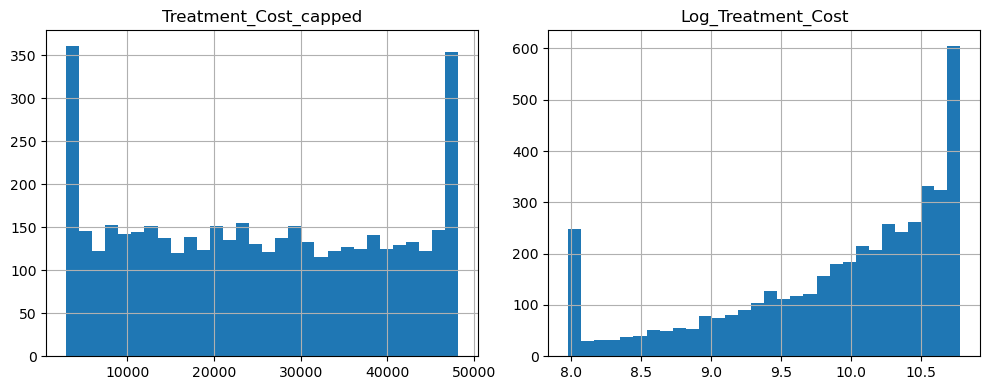



 Because Treatment_Cost is highly right‑skewed, I applied a log transformation to reduce skewness and stabilize the variance. I created a new variable Log_Treatment_Cost using log1p (log(1 + x)) on the capped cost values, which safely handles any zero costs.Log_Treatment_Cost = log(1 + Treatment_Cost_capped). Comparing summary statistics and distributions before and after transformation shows that the raw Treatment_Cost_capped variable is highly skewed with a wide range, whereas Log_Treatment_Cost has a more compressed range and a more symmetric distribution. This makes the variable more suitable for modeling and statistical analysis.


In [69]:
#Q8. Transformation
#Scenario: 
 #Treatment cost is highly skewed.
#Task:
#Apply log transformation
#Create a new column
#Compare before vs after distribution

import numpy as np

df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost_capped'])
# if you want to use the original Treatment_Cost instead:
# df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

df[['Treatment_Cost_capped', 'Log_Treatment_Cost']].describe()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df['Treatment_Cost_capped'].hist(bins=30)
plt.title('Treatment_Cost_capped')

plt.subplot(1,2,2)
df['Log_Treatment_Cost'].hist(bins=30)
plt.title('Log_Treatment_Cost')

plt.tight_layout()
plt.show()

print("\n\n Because Treatment_Cost is highly right‑skewed, I applied a log transformation to reduce skewness and stabilize the variance. I created a new variable Log_Treatment_Cost using log1p (log(1 + x)) on the capped cost values, which safely handles any zero costs.Log_Treatment_Cost = log(1 + Treatment_Cost_capped). Comparing summary statistics and distributions before and after transformation shows that the raw Treatment_Cost_capped variable is highly skewed with a wide range, whereas Log_Treatment_Cost has a more compressed range and a more symmetric distribution. This makes the variable more suitable for modeling and statistical analysis.")


In [77]:
#Q9. Time-Based Missing Handling
#Scenario: 
# Admission dates should follow a logical sequence.
#Task:
#Sort data by Admission_Date
#Apply forward fill or backward fill where appropriate
#Justify your choice

import pandas as pd

df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df = df.sort_values(by='Admission_Date')
print(df['Admission_Date'].dtype)
print(df['Admission_Date'].isnull().sum())
df['Admission_Date_filled'] = df['Admission_Date'].ffill()

df['Admission_Date_filled'] = df['Admission_Date'].ffill().bfill()

print("\n\nI first converted Admission_Date to datetime and sorted the dataset in ascending order of admission date so that records follow a chronological sequence. To handle missing admission dates, I applied a time‑based imputation strategy using forward fill followed by backward fill:\nAdmission_Date_filled = Admission_Date.sort_values().ffill().bfill(). Forward fill propagates the most recent known admission date to subsequent missing entries, which is reasonable when records are ordered in time and missing values occur between valid dates. Backward fill is then applied only to any remaining missing values at the start of the dataset, using the next available date. This approach maintains a logical temporal sequence for admissions while avoiding arbitrary date assignments")

datetime64[ns]
0


I first converted Admission_Date to datetime and sorted the dataset in ascending order of admission date so that records follow a chronological sequence. To handle missing admission dates, I applied a time‑based imputation strategy using forward fill followed by backward fill:
Admission_Date_filled = Admission_Date.sort_values().ffill().bfill(). Forward fill propagates the most recent known admission date to subsequent missing entries, which is reasonable when records are ordered in time and missing values occur between valid dates. Backward fill is then applied only to any remaining missing values at the start of the dataset, using the next available date. This approach maintains a logical temporal sequence for admissions while avoiding arbitrary date assignments
